# Live session run

End-to-end CNMFe run on a real recording sitting on the server. Just edit
`SESSION_RAW` in the next code cell and step through.

**Path layout** (mirrors the standard `0_raw / 1_preprocessed / 2_processed`
project tree):

- `0_raw/<session>/miniscope_video/*.avi`    — source AVIs (read-only)
- `1_preprocessed/<session>/miniscope_video/mc.zarr`      — motion-corrected zarr
- `1_preprocessed/<session>/miniscope_video/shifts.npy`   — per-frame (dy, dx)
- `2_processed/<session>/miniscope_video/mc_plots/`        — MC diagnostic plots
- `2_processed/<session>/miniscope_video/mc_downsampled.mp4` — every 10th frame, for visual QC
- `2_processed/<session>/miniscope_video/results/`         — CNMFe output (A, C, S, YrA, ...)

**Fused AVI → MC.** This notebook uses `CNMFe.fit_mc_from_avis(...)`,
which decodes the AVIs and applies motion correction in a single pass,
writing only `mc.zarr` to disk. No intermediate `session.zarr` is
materialised — that saves ~5 min and ~6 GB on a network mount for a
100k-frame session. If you specifically need the raw concatenated zarr
(for inspection / debugging), use the two-step `concat_avis_to_zarr` +
`CNMFe.fit_mc` workflow instead.

Each step is **idempotent**: if its output already exists, the cell reuses it
and skips the recompute. Delete the file/folder on disk if you want to redo a step.

## 1. Imports

In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Make the project root importable so 'concat_avis_to_zarr' resolves when
# running the notebook from anywhere (avi_mc imports from it).
PROJECT_ROOT = Path('/home/fs539/code/simpler_cnmfe')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from cnmfe.io import open_zarr
from cnmfe.pipeline import CNMFe, CNMFeParams
from concat_avis_to_zarr import _count_and_shape, _numeric_key

## 2. Session paths

Set `SESSION_RAW` to the raw `miniscope_video` folder. The `1_preprocessed`
and `2_processed` paths are derived by string-replacing `0_raw` in the raw
path — so the session id and any sub-structure are preserved automatically.

In [2]:
# --- EDIT ME -----------------------------------------------------------------
SESSION_RAW = Path(
    '/media/server/archive/projects/2023_intercontext/ToneComparison/'
    'data/0_raw/20260520_m0000159_som_1145/miniscope_video'
)
# -----------------------------------------------------------------------------

def _swap_stage(p: Path, new_stage: str) -> Path:
    """Replace the '0_raw' segment with `new_stage` in a path."""
    parts = list(p.parts)
    try:
        i = parts.index('0_raw')
    except ValueError as exc:
        raise ValueError(
            f"Expected '0_raw' in path {p}; can't derive {new_stage} location."
        ) from exc
    parts[i] = new_stage
    return Path(*parts)

SESSION_PREPROC = _swap_stage(SESSION_RAW, '1_preprocessed')
SESSION_PROC    = _swap_stage(SESSION_RAW, '2_processed')

RAW_AVI_DIR = SESSION_RAW
MC_ZARR     = SESSION_PREPROC / 'mc.zarr'
SHIFTS_NPY  = SESSION_PREPROC / 'shifts.npy'
MC_PLOTS    = SESSION_PROC / 'mc_plots'
MC_MP4      = SESSION_PROC / 'mc_downsampled.mp4'
RESULTS_DIR = SESSION_PROC / 'results'

SESSION_PREPROC.mkdir(parents=True, exist_ok=True)
SESSION_PROC.mkdir(parents=True, exist_ok=True)
MC_PLOTS.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Raw AVIs  :', RAW_AVI_DIR)
print('MC zarr  ->', MC_ZARR)
print('Shifts   ->', SHIFTS_NPY)
print('MC plots ->', MC_PLOTS)
print('MC mp4   ->', MC_MP4)
print('Results  ->', RESULTS_DIR)

assert RAW_AVI_DIR.is_dir(), f'Raw folder does not exist: {RAW_AVI_DIR}'

Raw AVIs  : /media/server/archive/projects/2023_intercontext/ToneComparison/data/0_raw/20260520_m0000159_som_1145/miniscope_video
MC zarr  -> /media/server/archive/projects/2023_intercontext/ToneComparison/data/1_preprocessed/20260520_m0000159_som_1145/miniscope_video/mc.zarr
Shifts   -> /media/server/archive/projects/2023_intercontext/ToneComparison/data/1_preprocessed/20260520_m0000159_som_1145/miniscope_video/shifts.npy
MC plots -> /media/server/archive/projects/2023_intercontext/ToneComparison/data/2_processed/20260520_m0000159_som_1145/miniscope_video/mc_plots
MC mp4   -> /media/server/archive/projects/2023_intercontext/ToneComparison/data/2_processed/20260520_m0000159_som_1145/miniscope_video/mc_downsampled.mp4
Results  -> /media/server/archive/projects/2023_intercontext/ToneComparison/data/2_processed/20260520_m0000159_som_1145/miniscope_video/results


## 3. Discover AVIs + light raw inspection

**3a.** List the numerically-named AVIs (`0.avi`, `1.avi`, ...) and sanity-
check counts/dimensions. (This is the same pre-scan that `fit_mc_from_avis`
does internally, but running it here surfaces problems early.)

**3b.** Pull a few sample frames + a coarse mean projection straight from
the AVIs (no zarr needed) so you can eyeball the recording before MC runs.
Used later as the "raw" half of the before/after diagnostic plots.

In [3]:
avis = sorted(RAW_AVI_DIR.glob('*.avi'), key=_numeric_key)
avis = [p for p in avis if _numeric_key(p) >= 0]
assert avis, f'No numerically-named AVIs in {RAW_AVI_DIR}'

print(f'{len(avis)} AVI file(s) in {RAW_AVI_DIR}:\n')
total = 0
H_raw = W_raw = None
for p in avis:
    n, h, w = _count_and_shape(p)
    total += n
    if H_raw is None:
        H_raw, W_raw = h, w
    print(f'  {p.name:>16s}  {n:>6d} frames  {h}x{w}')
print(f'\n  TOTAL          {total:>6d} frames  {H_raw}x{W_raw}')

100 AVI file(s) in /media/server/archive/projects/2023_intercontext/ToneComparison/data/0_raw/20260520_m0000159_som_1145/miniscope_video:

             0.avi    1000 frames  600x600
             1.avi    1000 frames  600x600
             2.avi    1000 frames  600x600
             3.avi    1000 frames  600x600
             4.avi    1000 frames  600x600
             5.avi    1000 frames  600x600
             6.avi    1000 frames  600x600
             7.avi    1000 frames  600x600
             8.avi    1000 frames  600x600
             9.avi    1000 frames  600x600
            10.avi    1000 frames  600x600
            11.avi    1000 frames  600x600
            12.avi    1000 frames  600x600
            13.avi    1000 frames  600x600
            14.avi    1000 frames  600x600
            15.avi    1000 frames  600x600
            16.avi    1000 frames  600x600
            17.avi    1000 frames  600x600
            18.avi    1000 frames  600x600
            19.avi    1000 frames  600x600
 

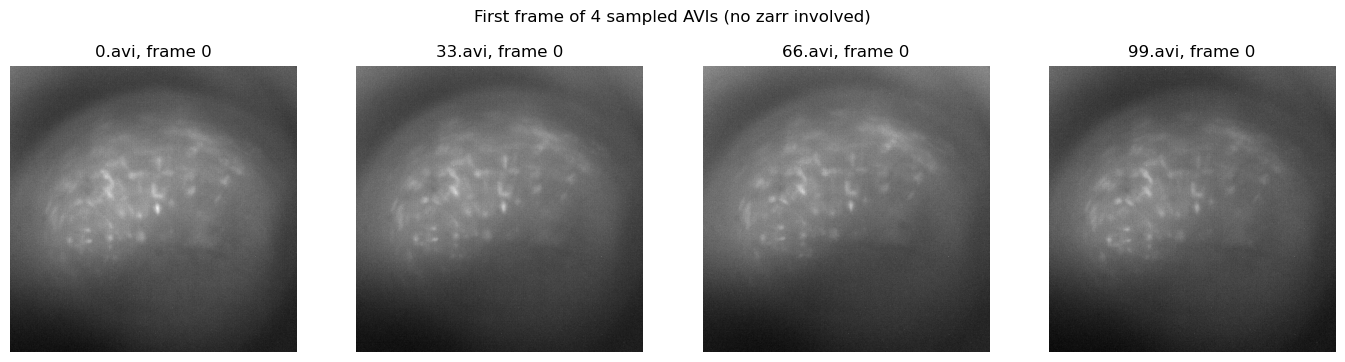

In [4]:
# Pull a few evenly-spaced frames straight from the AVIs (no zarr).
# Reuses the same luma-gray decoder the MC path will use.
import av

def _decode_first_frame(avi_path: Path) -> np.ndarray:
    container = av.open(str(avi_path))
    try:
        stream = container.streams.video[0]
        stream.thread_type = 'FRAME'
        for frame in container.decode(stream):
            return frame.to_ndarray(format='gray8')
    finally:
        container.close()
    raise RuntimeError(f'{avi_path} has no frames')

sample_picks = np.linspace(0, len(avis) - 1, 4).astype(int)
sample = np.stack([_decode_first_frame(avis[i]) for i in sample_picks], axis=0)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, i, img in zip(axes, sample_picks, sample):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{avis[i].name}, frame 0')
    ax.axis('off')
fig.suptitle('First frame of 4 sampled AVIs (no zarr involved)', y=1.02)
plt.tight_layout()
plt.show()

raw inspection sample: (600, 600)  (decoded 24.4s)


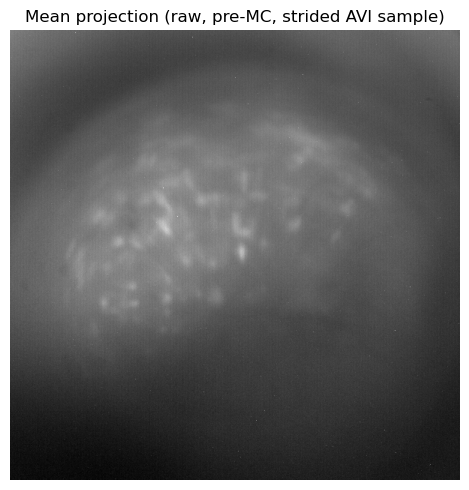

In [5]:
# Coarse raw mean projection: decode every Nth frame from ~12 strided AVIs,
# average them in RAM. Light enough to run before MC; gives us a "before"
# baseline for the diagnostic plots later.
def avi_mean_and_median(avi_paths, max_avis: int = 12, stride_within: int = 50):
    """Decode strided frames from a strided AVI subset; return (mean, median)
    images.
    """
    k = min(max_avis, len(avi_paths))
    picks = np.linspace(0, len(avi_paths) - 1, k).astype(int)
    pool = []
    for i in picks:
        container = av.open(str(avi_paths[i]))
        try:
            stream = container.streams.video[0]
            stream.thread_type = 'FRAME'
            for j, frame in enumerate(container.decode(stream)):
                if j % stride_within == 0:
                    pool.append(frame.to_ndarray(format='gray8'))
        finally:
            container.close()
    sampled = np.stack(pool, axis=0).astype(np.float32)
    return sampled.mean(axis=0), np.median(sampled, axis=0)

t0 = time.time()
raw_mean, raw_tmpl = avi_mean_and_median(avis)
H_raw, W_raw = raw_mean.shape
print(f'raw inspection sample: {raw_mean.shape}  '
      f'(decoded {time.time() - t0:.1f}s)')

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(raw_mean, cmap='gray')
ax.set_title('Mean projection (raw, pre-MC, strided AVI sample)')
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Motion correction — fused AVI → `mc.zarr` in one pass

`CNMFe.fit_mc_from_avis` decodes the AVIs and applies rigid motion
correction in a single pipeline, writing only `mc.zarr` to disk. Peak RAM
≈ `(mc_batch_size + mc_template_max_frames) * H * W * 4` bytes,
independent of total T.

**`mc_n_iter` must be 1.** For multi-iteration MC use the separate
`concat_avis_to_zarr` + `CNMFe.fit_mc` flow (the template has to be
rebuilt from the corrected output of each pass, which needs the
intermediate zarr).

If `mc.zarr` already exists this cell reuses it (delete the folder on disk
to re-run).

In [6]:
params = CNMFeParams(
    # MC
    max_shift=(20, 20),
    upsample_factor=10,
    mc_n_iter=1,                   # fused path only supports 1; bump to 2+ needs the two-step flow
    mc_gSig_filt=7,                # 1p high-pass sigma; set None for 2p
    mc_batch_size=1000,
    mc_template_max_frames=2000,
    mc_output_chunk_t=None,        # default = mc_batch_size
    mc_output_dtype='float32',
    # CNMFe (used in section 7)
    sigma=5.0,
    min_corr=0.8,
    min_pnr=10.0,
    n_iter_main=1,
    n_iter_temporal=2,
    merge_thr_corr=0.85,
    merge_thr_overlap=0.5,
    spatial_max_thr=0.1,
    n_jobs=-1,
)
peak_mb = (params.mc_batch_size + params.mc_template_max_frames) * H_raw * W_raw * 4 / 1e6
print(f'estimated MC peak RAM: ~{peak_mb:.0f} MB')

estimated MC peak RAM: ~4320 MB


In [ ]:
model_mc = CNMFe(params)

t0 = time.time()
mc = model_mc.fit_mc_from_avis(
    RAW_AVI_DIR,
    output_dir=SESSION_PREPROC,
    skip_if_exists=True,
)
print(f'\nfused MC elapsed: {time.time() - t0:.1f}s')

T_mc, H, W = mc.shape
print(f'\nmc shape  : {mc.shape}')
print(f'mc chunks : {mc.chunks}')
print(f'mc dtype  : {mc.dtype}')
print(f'shifts    : {None if model_mc.shifts is None else model_mc.shifts.shape}')

Found 100 AVI files: 0.avi ... 99.avi
Scanning frame counts ...
  0.avi: 1000 frames  (600x600)
  1.avi: 1000 frames  (600x600)
  2.avi: 1000 frames  (600x600)
  3.avi: 1000 frames  (600x600)
  4.avi: 1000 frames  (600x600)
  5.avi: 1000 frames  (600x600)
  6.avi: 1000 frames  (600x600)
  7.avi: 1000 frames  (600x600)
  8.avi: 1000 frames  (600x600)
  9.avi: 1000 frames  (600x600)
  10.avi: 1000 frames  (600x600)
  11.avi: 1000 frames  (600x600)
  12.avi: 1000 frames  (600x600)
  13.avi: 1000 frames  (600x600)
  14.avi: 1000 frames  (600x600)
  15.avi: 1000 frames  (600x600)
  16.avi: 1000 frames  (600x600)
  17.avi: 1000 frames  (600x600)
  18.avi: 1000 frames  (600x600)
  19.avi: 1000 frames  (600x600)
  20.avi: 1000 frames  (600x600)
  21.avi: 1000 frames  (600x600)
  22.avi: 1000 frames  (600x600)
  23.avi: 1000 frames  (600x600)
  24.avi: 1000 frames  (600x600)
  25.avi: 1000 frames  (600x600)
  26.avi: 1000 frames  (600x600)
  27.avi: 1000 frames  (600x600)
  28.avi: 1000 frames 

template decode: 100%|██████████| 9287/9287 [00:15<00:00, 592.72frame/s] 



Writing -> /media/server/archive/projects/2023_intercontext/ToneComparison/data/1_preprocessed/20260520_m0000159_som_1145/miniscope_video/mc.zarr
  shape=(99287, 600, 600)  chunks=(1000, 600, 600)  dtype=float32


decode+MC+write:  88%|████████▊ | 87000/99287 [24:09<03:13, 63.61frame/s] 

## 5. MC diagnostics

Three plots, all written to `MC_PLOTS/`:

- **shifts.png** — per-frame `(dy, dx)` over time. Spikes that exceed
  `max_shift` are clipped — if you see flat-top saturation, bump
  `params.max_shift`.
- **mean_before_after.png** — raw mean (from the strided AVI sample
  in section 3b) vs the corrected mean (streamed over `mc.zarr`).
  Vasculature and bright structures should sharpen visibly.
- **template_before_after.png** — same idea but median-based; more
  robust to occasional bright bursts.

In [ ]:
if model_mc.shifts is not None:
    shifts = np.asarray(model_mc.shifts)
    fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    ax[0].plot(shifts[:, 0], lw=0.7)
    ax[0].set_ylabel('dy (px)')
    ax[0].axhline(0, color='k', lw=0.4)
    ax[0].grid(alpha=0.3)
    ax[1].plot(shifts[:, 1], lw=0.7, color='C1')
    ax[1].set_ylabel('dx (px)')
    ax[1].set_xlabel('frame')
    ax[1].axhline(0, color='k', lw=0.4)
    ax[1].grid(alpha=0.3)
    fig.suptitle(f'Motion correction shifts  (peak |dy|={np.abs(shifts[:,0]).max():.2f}, '
                 f'peak |dx|={np.abs(shifts[:,1]).max():.2f})')
    plt.tight_layout()
    out = MC_PLOTS / 'shifts.png'
    fig.savefig(out, dpi=120)
    plt.show()
    print(f'wrote {out}')
else:
    print('no shifts available; skipping plot')

In [ ]:
# Corrected mean projection — streamed over the mc.zarr.
def mean_projection(zarr_arr, batch_size: int = 500) -> np.ndarray:
    """Streamed mean projection; RAM ~ batch_size * H * W * 8 bytes."""
    T = zarr_arr.shape[0]
    acc = np.zeros(zarr_arr.shape[1:], dtype=np.float64)
    for start in range(0, T, batch_size):
        end = min(start + batch_size, T)
        acc += np.asarray(zarr_arr[start:end], dtype=np.float64).sum(axis=0)
    return (acc / T).astype(np.float32)

mc_mean = mean_projection(mc)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw_mean, cmap='gray')
axes[0].set_title('mean (raw, strided AVI sample)')
axes[0].axis('off')
axes[1].imshow(mc_mean, cmap='gray')
axes[1].set_title('mean (motion-corrected, full)')
axes[1].axis('off')
plt.tight_layout()
out = MC_PLOTS / 'mean_before_after.png'
fig.savefig(out, dpi=120)
plt.show()
print(f'wrote {out}')

In [ ]:
# Corrected median template — strided sample of mc.zarr.
def strided_median(zarr_arr, max_frames: int = 800) -> np.ndarray:
    """Median projection from a strided sample — robust to bright transients."""
    T = zarr_arr.shape[0]
    idx = np.linspace(0, T - 1, min(T, max_frames)).astype(int)
    sample = np.stack([np.asarray(zarr_arr[i]) for i in idx], axis=0)
    return np.median(sample.astype(np.float32), axis=0)

mc_tmpl = strided_median(mc)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw_tmpl, cmap='gray')
axes[0].set_title('median template (raw, strided AVI sample)')
axes[0].axis('off')
axes[1].imshow(mc_tmpl, cmap='gray')
axes[1].set_title('median template (motion-corrected, full)')
axes[1].axis('off')
plt.tight_layout()
out = MC_PLOTS / 'template_before_after.png'
fig.savefig(out, dpi=120)
plt.show()
print(f'wrote {out}')

## 6. Downsampled MC video for visual QC

Every Nth frame of the corrected zarr written as a small mp4. The intensity
is normalised to the 0.5–99.5 percentile range so the result is viewable
regardless of the source units.

Cell is idempotent: skips if `MC_MP4` already exists.

In [ ]:
STRIDE  = 10        # save every 10th frame
FPS_OUT = 20.0      # playback speed of the produced mp4

if MC_MP4.exists():
    print(f'{MC_MP4} already exists, skipping (delete to re-render)')
else:
    idx = np.arange(0, T_mc, STRIDE)
    print(f'rendering {len(idx)} frames (every {STRIDE}th of {T_mc})...')

    # Streaming percentile estimate from a sample to set robust display range.
    sample = np.stack([np.asarray(mc[i]) for i in np.linspace(0, T_mc - 1, 200).astype(int)])
    lo = float(np.percentile(sample, 0.5))
    hi = float(np.percentile(sample, 99.5))
    print(f'display range: [{lo:.2f}, {hi:.2f}]')

    import cv2
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    H_mc, W_mc = mc.shape[1], mc.shape[2]
    writer = cv2.VideoWriter(str(MC_MP4), fourcc, FPS_OUT, (W_mc, H_mc), isColor=False)
    if not writer.isOpened():
        raise RuntimeError(f'cv2.VideoWriter failed to open {MC_MP4}')

    t0 = time.time()
    try:
        for k, i in enumerate(idx):
            frame = np.asarray(mc[int(i)], dtype=np.float32)
            frame = np.clip((frame - lo) / (hi - lo + 1e-8), 0.0, 1.0)
            writer.write((frame * 255).astype(np.uint8))
            if (k + 1) % 200 == 0:
                print(f'  wrote {k + 1} / {len(idx)} frames')
    finally:
        writer.release()

    print(f'\nwrote {MC_MP4}  ({time.time() - t0:.1f}s)')

## 7. CNMFe extraction

Runs the full pipeline on `mc.zarr` with `do_motion_correction=False`
(we already did MC). For very long recordings (60k+ frames) the in-RAM
materialisation here will be the bottleneck — in that case switch to the
streaming path documented in `demo_notebooks/02_extract_components.ipynb`
(Section 9).

If the results folder already contains `manifest.json` we reload it instead
of re-running.

In [ ]:
if (RESULTS_DIR / 'manifest.json').exists():
    print(f'results already present in {RESULTS_DIR}; reloading')
    print('(delete manifest.json to re-run)')
    model = CNMFe.load(RESULTS_DIR)
else:
    ram_gb = T_mc * H * W * 4 / 1e9
    print(f'loading mc.zarr into RAM ({T_mc} x {H} x {W} float32 ≈ {ram_gb:.1f} GB)...')
    t0 = time.time()
    movie = np.asarray(mc, dtype=np.float32)
    print(f'  loaded in {time.time() - t0:.1f}s')

    t0 = time.time()
    model = CNMFe(params).fit(movie, do_motion_correction=False)
    elapsed = time.time() - t0
    print(f'\nextracted {model.A.shape[1]} components in {elapsed:.1f}s')

    model.save(RESULTS_DIR)
    (RESULTS_DIR / 'run_info.json').write_text(json.dumps({
        'session_raw'   : str(SESSION_RAW),
        'mc_zarr'       : str(MC_ZARR),
        'movie_shape'   : [int(T_mc), int(H), int(W)],
        'K_extracted'   : int(model.A.shape[1]),
        'wall_time_s'   : round(elapsed, 2),
    }, indent=2))
    print(f'saved → {RESULTS_DIR}')

## 8. Inspect results

- Footprints overlaid on the mean image (red = auto-accepted, grey = rejected).
- A handful of representative traces (`C`, `C + YrA`, `S`).

Both plots are also written to `MC_PLOTS/` next to the MC diagnostics so
everything visual lives in one place.

In [ ]:
K = model.A.shape[1]
A_dense = np.asarray(model.A.todense()).reshape(H, W, K)
accepted = getattr(model, 'accepted_mask', np.ones(K, dtype=bool))

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(mc_mean, cmap='gray')
for k in range(K):
    fp = A_dense[..., k]
    if fp.max() <= 0:
        continue
    color = 'red' if accepted[k] else '0.6'
    ax.contour(fp, levels=[fp.max() * 0.3], colors=color, linewidths=0.7)
ax.set_title(f'{int(accepted.sum())} accepted / {K} total components')
ax.axis('off')
plt.tight_layout()
out = MC_PLOTS / 'footprints_overlay.png'
fig.savefig(out, dpi=120)
plt.show()
print(f'wrote {out}')

In [ ]:
n_show = min(8, K)
if n_show == 0:
    print('no components to plot')
else:
    # Show the top-n_show by trace amplitude among accepted components.
    accepted_idx = np.where(accepted)[0]
    pool = accepted_idx if accepted_idx.size else np.arange(K)
    order = pool[np.argsort(-(model.C[pool]).max(axis=1))][:n_show]

    fig, axes = plt.subplots(n_show, 1, figsize=(11, 1.3 * n_show), sharex=True)
    if n_show == 1:
        axes = [axes]
    for ax, k in zip(axes, order):
        proj = model.C[k] + model.YrA[k]
        ax.plot(proj, color='0.6', lw=0.6, label='C + YrA')
        ax.plot(model.C[k], color='C0', lw=0.9, label='C')
        s = model.S[k]
        if s.max() > 0:
            ax.vlines(np.where(s > 0)[0], 0, model.C[k].max(),
                      color='C3', lw=0.5, alpha=0.4)
        ax.set_ylabel(f'k={k}')
        ax.set_yticks([])
    axes[0].legend(loc='upper right', fontsize=8)
    axes[-1].set_xlabel('frame')
    fig.suptitle('Top components: C (clean), C+YrA (projected), S (spikes)', y=1.01)
    plt.tight_layout()
    out = MC_PLOTS / 'traces.png'
    fig.savefig(out, dpi=120)
    plt.show()
    print(f'wrote {out}')

## Output summary

All artifacts for this session:

```
1_preprocessed/<session>/miniscope_video/
  mc.zarr                # motion-corrected, float32   (only output of the fused step)
  shifts.npy             # (T, 2) per-frame (dy, dx)

2_processed/<session>/miniscope_video/
  mc_plots/
    shifts.png
    mean_before_after.png
    template_before_after.png
    footprints_overlay.png
    traces.png
  mc_downsampled.mp4     # every 10th frame, normalised
  results/
    A.npz                # sparse footprints (H*W, K)
    C.npy                # deconvolved traces (K, T)
    S.npy                # spike trains (K, T)
    YrA.npy              # residuals; C + YrA = projected trace
    C_raw.npy            # init traces (K, T)
    sn.npy               # noise std (H, W)
    sn_per_k.npy g.npy   # AR params used
    b0.npy W.npz         # ring background
    accepted_mask.npy    # per-component pass/fail (npix + SNR)
    eval_info.npz        # detailed per-component eval stats
    params.json          # CNMFeParams
    manifest.json        # dims, K, T
    run_info.json        # session paths + wall time
```

Reload anywhere:

```python
from cnmfe.pipeline import CNMFe
model = CNMFe.load('/.../2_processed/<session>/miniscope_video/results')
A, C, S, YrA = model.A, model.C, model.S, model.YrA
```

**Note**: the intermediate `session.zarr` (raw concatenated AVIs) is no
longer written. If you need it for debugging, use:

```python
from concat_avis_to_zarr import concat_avis_to_zarr
concat_avis_to_zarr(RAW_AVI_DIR, SESSION_PREPROC / 'session.zarr',
                    skip_if_exists=True)
```